# 확인: 변화율이 음수인 지역은 인천뿐인가?
`EDA_Incheon.ipynb` 6장의 시도별 차트에 대한 시각 확인. ① 변화율 정의를 바꿔도 시도 단위에서 인천만 음수인지, ② 시군구 단위로 내려가면 다른 음수 지역이 어디에 있는지.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib import font_manager as fm

_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if _f in _avail: mpl.rc("font", family=_f); break
mpl.rc("axes", unicode_minus=False)
C = {"인천": "#2a78d6", "neg": "#e34948", "pos": "#c3c2b7", "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#898781", "grid": "#e1e0d9", "ref": "#c3c2b7"}
mpl.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C["ref"], "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": C["ink2"], "ytick.color": C["ink2"], "axes.titlecolor": C["ink"], "axes.titlesize": 10.5,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "legend.frameon": False, "legend.fontsize": 9})

df = pd.read_csv("ABP_CONTEST_DATA.csv", dtype={"GENDER_CD": str, "AGE_CD": str, "TP_BUZ_NO": str})
df["region"] = df.SIDO_NM + " " + df.CCG_NM
ind = df[df.GENDER_CD.isin(["1", "2"])]                       # 내국인 개인
SIDO_SHORT = {"강원특별자치도": "강원", "전북특별자치도": "전북", "세종특별자치시": "세종", "제주특별자치도": "제주"}
short = lambda s: SIDO_SHORT.get(s, s.replace("광역시", "").replace("특별시", "").replace("도", "도"))

def change(d, by, col="amt", pre=(202601, 202602, 202603, 202604), post=(202605, 202606)):
    a = d[d.STRD_YYMM.isin(pre)].groupby(by)[col].sum() / len(pre)
    b = d[d.STRD_YYMM.isin(post)].groupby(by)[col].sum() / len(post)
    return (b / a - 1) * 100

## ① 시도 단위 — 변화율 정의 6가지

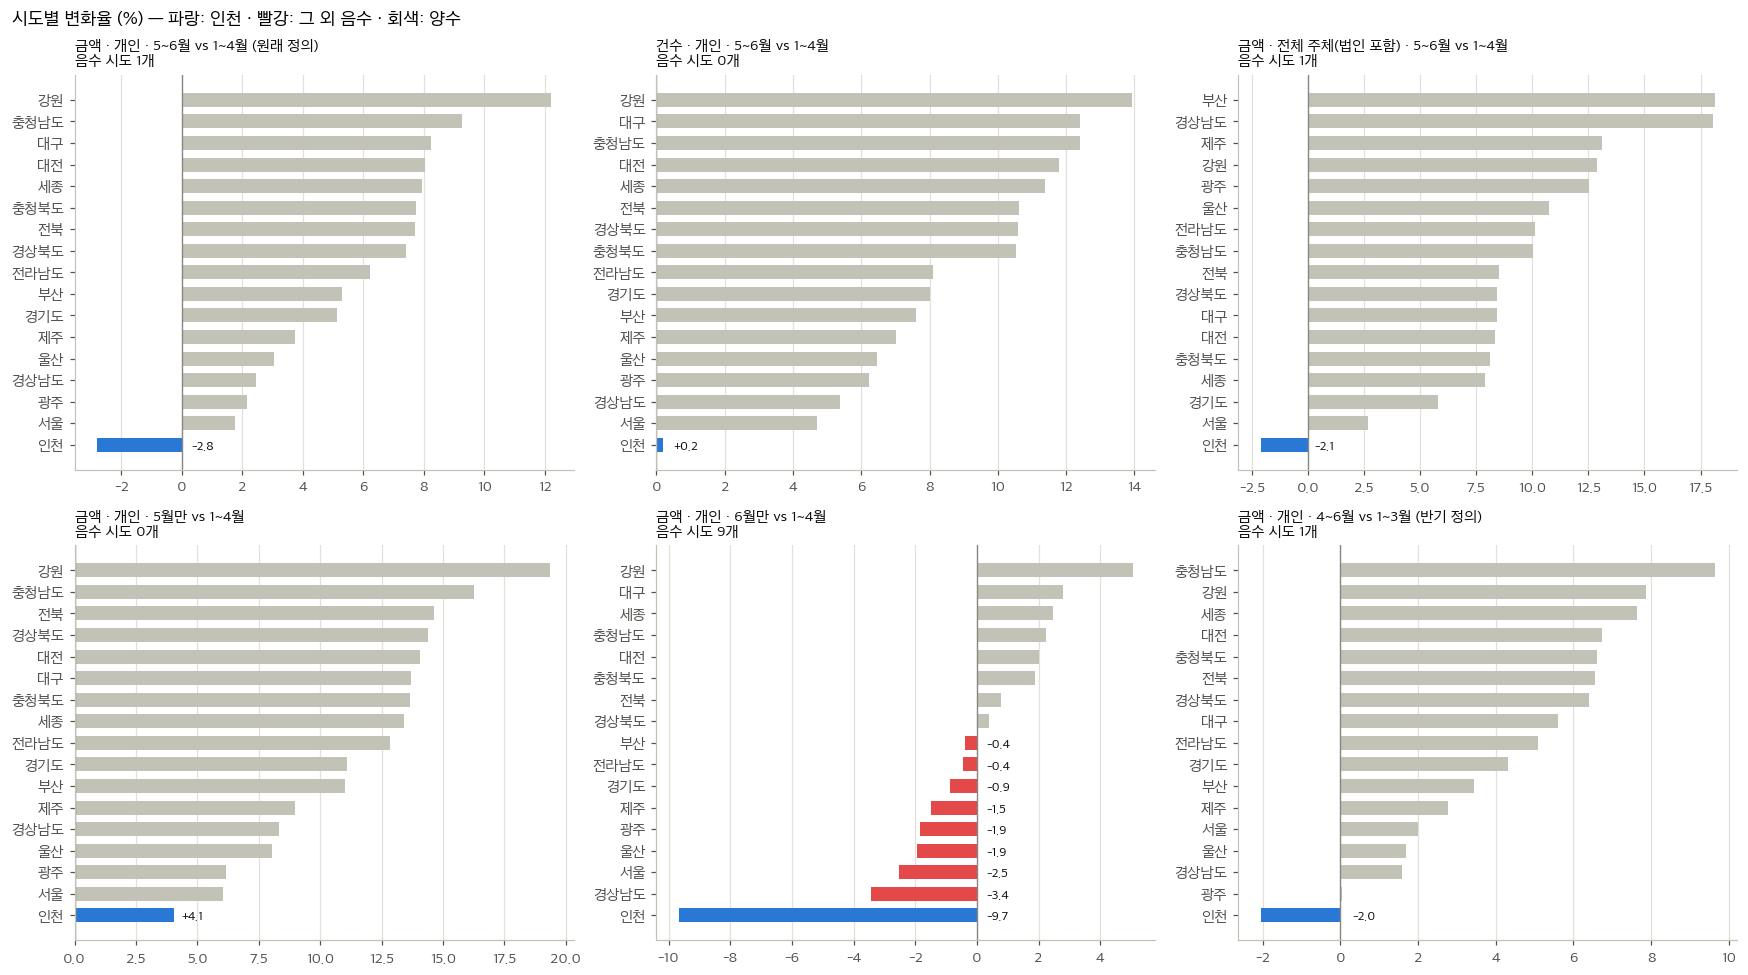

In [2]:
DEFS = {
    "금액 · 개인 · 5~6월 vs 1~4월 (원래 정의)": dict(d=ind, col="amt"),
    "건수 · 개인 · 5~6월 vs 1~4월":             dict(d=ind, col="cnt"),
    "금액 · 전체 주체(법인 포함) · 5~6월 vs 1~4월": dict(d=df, col="amt"),
    "금액 · 개인 · 5월만 vs 1~4월":             dict(d=ind, col="amt", post=(202605,)),
    "금액 · 개인 · 6월만 vs 1~4월":             dict(d=ind, col="amt", post=(202606,)),
    "금액 · 개인 · 4~6월 vs 1~3월 (반기 정의)":  dict(d=ind, col="amt", pre=(202601, 202602, 202603), post=(202604, 202605, 202606)),
}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (title, kw) in zip(axes.flat, DEFS.items()):
    s = change(kw["d"], "SIDO_NM", kw["col"], kw.get("pre", (202601, 202602, 202603, 202604)), kw.get("post", (202605, 202606))).sort_values()
    colors = [C["인천"] if r == "인천광역시" else (C["neg"] if v < 0 else C["pos"]) for r, v in s.items()]
    ax.barh([short(r) for r in s.index], s.values, color=colors, height=0.65)
    for i, (r, v) in enumerate(s.items()):
        if v < 0 or r == "인천광역시":
            ax.text(0.3 if v < 0 else v + 0.3, i, f"{v:+.1f}", va="center", ha="left", fontsize=8.5, color=C["ink"])
    ax.axvline(0, color=C["muted"], lw=0.9); ax.grid(axis="y", visible=False)
    n_neg = int((s < 0).sum())
    ax.set_title(f"{title}\n음수 시도 {n_neg}개", fontsize=10)
fig.suptitle("시도별 변화율 (%) — 파랑: 인천 · 빨강: 그 외 음수 · 회색: 양수", x=0.01, ha="left", fontsize=12, fontweight="semibold")
plt.tight_layout(); plt.show()

## ② 시군구 단위 — 시도별 시군구 분포 (점 하나 = 시군구)

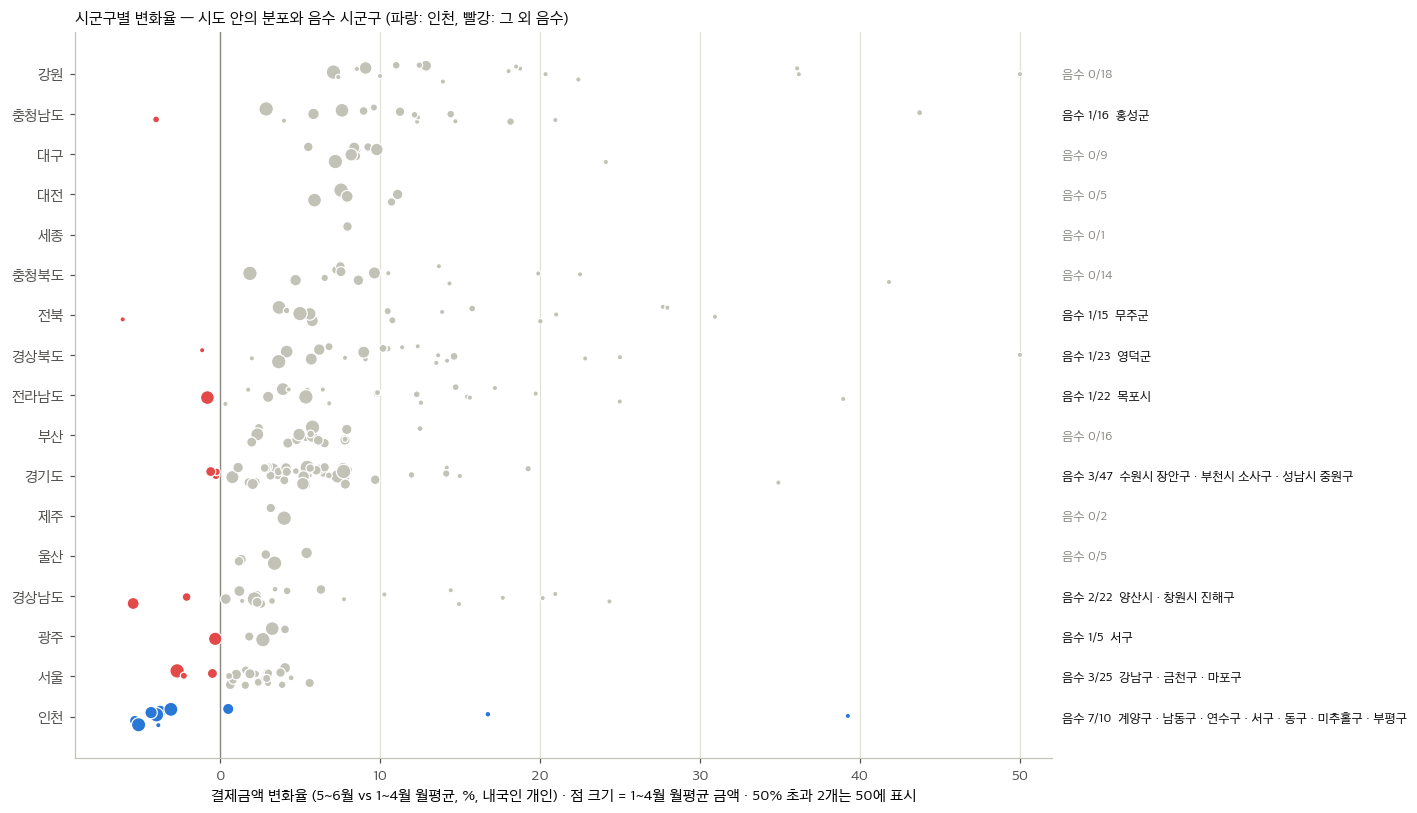

음수 시군구 20개 / 전체 255개  (인천 7개)


,변화율 %,1~4월 월평균 금액(억)
region,,
전북특별자치도 무주군,-6.1,7.9
경상남도 양산시,-5.4,173.1
인천광역시 계양구,-5.3,115.5
인천광역시 남동구,-5.1,202.0
인천광역시 연수구,-4.3,154.3
충청남도 홍성군,-4.0,36.9
인천광역시 서구,-4.0,209.3
인천광역시 동구,-3.9,25.4
인천광역시 미추홀구,-3.7,140.9


In [3]:
reg = change(ind, "region")                                    # 원래 정의: 금액 · 개인 · 5~6월 vs 1~4월
pre_amt = ind[ind.STRD_YYMM <= 202604].groupby("region").amt.sum() / 4
sido_of = reg.index.str.split(" ").str[0]
order = change(ind, "SIDO_NM").sort_values().index              # 시도 변화율 낮은 순

fig, ax = plt.subplots(figsize=(13, 7.5))
import matplotlib.transforms as mtrans
tr = mtrans.blended_transform_factory(ax.transAxes, ax.transData)      # x: 축 비율, y: 데이터
XMAX = 50; rng = np.random.default_rng(0); n_out = int((reg > XMAX).sum())
for i, sd in enumerate(order):
    v = reg[sido_of == sd]; w = pre_amt[v.index]
    jit = rng.uniform(-0.22, 0.22, len(v))
    col = [C["인천"] if sd == "인천광역시" else (C["neg"] if x < 0 else C["pos"]) for x in v]
    ax.scatter(v.clip(upper=XMAX).values, i + jit, s=np.clip(w / w.max() * 90, 12, 90) if sd != "세종특별자치시" else 40,
               c=col, ec="white", lw=0.8, zorder=3)
    neg = v[v < 0].sort_values()
    names = " · ".join(r.split(" ", 1)[1] for r in neg.index)
    ax.text(1.01, i, f"음수 {len(neg)}/{len(v)}" + (f"  {names}" if len(neg) else ""), transform=tr,
            va="center", fontsize=8.5, color=C["ink"] if len(neg) else C["muted"])
ax.set_yticks(range(len(order))); ax.set_yticklabels([short(s) for s in order])
ax.axvline(0, color=C["muted"], lw=0.9); ax.grid(axis="y", visible=False)
ax.set_xlim(reg.min() - 3, XMAX + 2)
ax.set_xlabel(f"결제금액 변화율 (5~6월 vs 1~4월 월평균, %, 내국인 개인) · 점 크기 = 1~4월 월평균 금액 · {XMAX}% 초과 {n_out}개는 {XMAX}에 표시")
ax.set_title("시군구별 변화율 — 시도 안의 분포와 음수 시군구 (파랑: 인천, 빨강: 그 외 음수)")
plt.tight_layout(); plt.show()

neg_idx = reg[reg < 0].sort_values().index
neg_tab = pd.DataFrame({"변화율 %": reg[neg_idx].round(1), "1~4월 월평균 금액(억)": (pre_amt[neg_idx] / 1e8).round(1)}).loc[neg_idx]
print(f"음수 시군구 {len(neg_tab)}개 / 전체 {len(reg)}개  (인천 {int(neg_tab.index.str.startswith('인천').sum())}개)")
display(neg_tab)